# `CRO` fitting with CMIP6 models

This tutorial illustrates how to use the `mCRO` to estimate RO parameters from all CMIP6 models

This notebook was contributed by [Soong-Ki Kim](https://csd.postech.ac.kr/professor).


## Load ENSO time series from CMIP6 models


We begin by loading monthly Niño3.4 SST anomalies and equatorial Pacific Warm Water Volume (WWV; stored as Hm in the CRO CMIP6 dataset) for all CMIP6 historical simulations included in the CRO data file.

The Python version uses pyCRO.ROdata_load(name="CMIP6"). The MATLAB version does not include an equivalent convenience loader, so the NetCDF file is loaded manually. 

The CRO CMIP6 dataset contains 48 models. In the MATLAB data layout used here, time is the first dimension and model is the second dimension, so each model is passed to RO_fitting as one column vector.


In [ ]:
fpath=pwd+"/Data/"+"CROdata_timeseries_cmip6.nc"; % replace the filename/path if needed

T_cmip=ncread(fpath,'Nino34');
h_cmip=ncread(fpath,'Hm');

% T_cmip and h_cmip: [time x model]
% The CRO CMIP6 dataset contains 48 historical model simulations.
nModel=size(T_cmip,2);

T_cmip=double(T_cmip);
h_cmip=double(h_cmip);

fprintf('Number of CMIP6 models: %d\n',nModel)
ncdisp(fpath)

Number of CMIP6 models: 48


Source:
           /Volumes/home/ENSO_Community_RO/Manuscript/WebManual_MATLAB/MATLAB_ipynb/Data/CROdata_timeseries_CMIP6.nc
Format:
           netcdf4
Dimensions:
           model = 48
           time  = 1332
Variables:
    Nino3 
           Size:       1332x48
           Dimensions: time,model
           Datatype:   single
           Attributes:
                       _FillValue = 1.000000020040877e+20
                       long_name  = UNSUPPORTED DATATYPE
    Nino34
           Size:       1332x48
           Dimensions: time,model
           Datatype:   single
           Attributes:
                       _FillValue = 1.000000020040877e+20
                       long_name  = UNSUPPORTED DATATYPE
    Hm    
           Size:       1332x48
           Dimensions: time,model
           Datatype:   single
           Attributes:
                       _FillValue = 1.000000020040877e+20
                       long_name  = UNSUPPORTED DATATYPE
    Hw    
           Size:       1332x48
     

## Fitting RO to all CMIP6 models


### Type 1: Linear-White-Additive


Fit a linear RO with white and additive noise to each CMIP6 model.


In [ ]:
par_option_T=struct("R",1,"F1",1,"b_T",0,"c_T",0,"d_T",0);
par_option_h=struct("F2",1,"epsilon",1,"b_h",0);
par_option_noise=struct("T","white","h","white","T_type","additive");

par_cmip_LWA=cell(nModel,1);

for imodel=1:nModel
    T=T_cmip(:,imodel);
    h=h_cmip(:,imodel);

    good=isfinite(T) & isfinite(h);
    par_cmip_LWA{imodel}=RO_fitting( ...
        T(good),h(good), ...
        par_option_T,par_option_h,par_option_noise);
end

par_cmip_LWA

par_cmip_LWA =
48×1 cell 배열
    {16×1 cell}
    {16×1 cell}
    {16×1 cell}
    {16×1 cell}
    {16×1 cell}
    {16×1 cell}
    {16×1 cell}
    {16×1 cell}
    {16×1 cell}
    {16×1 cell}
    {16×1 cell}
    {16×1 cell}
    {16×1 cell}
    {16×1 cell}
    {16×1 cell}
    {16×1 cell}


### Type 2: Nonlinear-White-Additive


Fit a nonlinear RO with white and additive noise to each CMIP6 model.


In [ ]:
par_option_T=struct("R",1,"F1",1,"b_T",1,"c_T",1,"d_T",1);
par_option_h=struct("F2",1,"epsilon",1,"b_h",1);
par_option_noise=struct("T","white","h","white","T_type","additive");

par_cmip_NWA=cell(nModel,1);

for imodel=1:nModel
    T=T_cmip(:,imodel);
    h=h_cmip(:,imodel);

    good=isfinite(T) & isfinite(h);
    par_cmip_NWA{imodel}=RO_fitting( ...
        T(good),h(good), ...
        par_option_T,par_option_h,par_option_noise);
end

par_cmip_NWA

par_cmip_NWA =
48×1 cell 배열
    {16×1 cell}
    {16×1 cell}
    {16×1 cell}
    {16×1 cell}
    {16×1 cell}
    {16×1 cell}
    {16×1 cell}
    {16×1 cell}
    {16×1 cell}
    {16×1 cell}
    {16×1 cell}
    {16×1 cell}
    {16×1 cell}
    {16×1 cell}
    {16×1 cell}
    {16×1 cell}


## Understanding the relationship between ENSO amplitude and RO parameters


### Calculation of ENSO variance

In [ ]:
cmip_var=var(T_cmip,1,1,'omitnan');
cmip_var=cmip_var(:);

### Relationship with BJ index and stochastic forcing amplitude


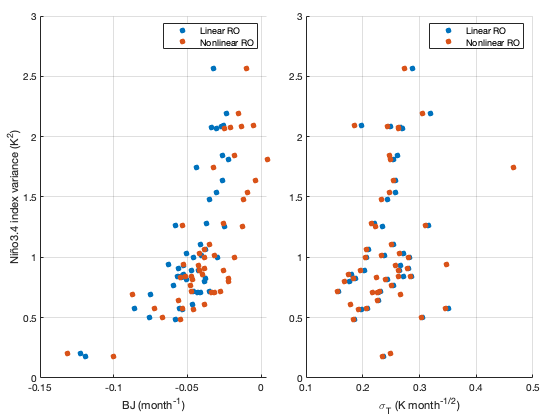

In [ ]:
BJ_cmip_LWA=nan(nModel,1);
BJ_cmip_NWA=nan(nModel,1);
sigmaT_cmip_LWA=nan(nModel,1);
sigmaT_cmip_NWA=nan(nModel,1);

for imodel=1:nModel
    par=par_cmip_LWA{imodel};
    R=par{1}(1);
    epsilon=par{4}(1);
    BJ_cmip_LWA(imodel)=0.5*(R-epsilon);
    sigmaT_cmip_LWA(imodel)=par{9}(1);

    par=par_cmip_NWA{imodel};
    R=par{1}(1);
    epsilon=par{4}(1);
    BJ_cmip_NWA(imodel)=0.5*(R-epsilon);
    sigmaT_cmip_NWA(imodel)=par{9}(1);
end

figure;
tiledlayout(1,2,'TileSpacing','compact','Padding','compact');

nexttile
scatter(BJ_cmip_LWA,cmip_var,36,'filled','DisplayName','Linear RO')
hold on
scatter(BJ_cmip_NWA,cmip_var,36,'filled','DisplayName','Nonlinear RO')
xlabel('BJ (month^{-1})')
ylabel('Niño3.4 index variance (K^2)')
legend('Location','best','FontSize',9)
grid on

nexttile
scatter(sigmaT_cmip_LWA,cmip_var,36,'filled','DisplayName','Linear RO')
hold on
scatter(sigmaT_cmip_NWA,cmip_var,36,'filled','DisplayName','Nonlinear RO')
xlabel('\sigma_T (K month^{-1/2})','Interpreter','tex')
legend('Location','best','FontSize',9)
grid on

The ENSO amplitude is highly related to the growth rate (BJ index), and to a lesser degree to the noise amplitude.
